# Scikit SGD: Minimal Training Pipeline

This notebook is the first concrete implementation of the Bovi Core training contracts. It trains a small `SGDRegressor` entirely on CPU and demonstrates configuration, data loading, transforms, training context, epoch results, local checkpoints, evaluation, and resume.

The example deliberately keeps orchestration and logging outside the trainer.

## Section 1: Configuration

In [1]:
from pathlib import Path

from bovi_core.config import Config
from bovi_core.ml import ModelProviderRegistry

Config.reset()
config = Config(experiment_name="scikit_sgd", project_name="scikit-sgd")

print(f"Environment: {config.environment}")
print(f"Project root: {config.project.project_root}")
print(f"Experiment: {config.experiment.experiment_name}")
print(f"Available providers: {ModelProviderRegistry.list_available()}")

🔄 Config singleton reset
🔧 Initializing Config...
   🌍 Environment: local
🔍 No TOML path passed, resolving path automatically
🔍 Found pyproject.toml in parent directory: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/scikit-sgd
      📋 Project name: scikit-sgd
      📁 Current working directory: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/scikit-sgd/notebooks/experiments/scikit_sgd
      📁 Traversed to: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/scikit-sgd
      📁 project_src: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/scikit-sgd/src
⚠️  .env file not specified or not found at: /home/douwe/work/code/bovi-analytics/bovi/.worktrees/concrete-trainer-example/packages/models/scikit-sgd/.env
   👤 Author: Douwe de Kok <douwedekok@gmail.com>
🔍 No config_file_path passed, resolving from:
      📁 proj

In [2]:
from scikit_sgd import (
    ScikitSGDEvaluationConfig,
    ScikitSGDModelConfig,
    ScikitSGDTrainingConfig,
)

model_config = ScikitSGDModelConfig.from_config(config)
training_config = ScikitSGDTrainingConfig.from_config(config)
evaluation_config = ScikitSGDEvaluationConfig.from_config(config)

print(f"Model config: {model_config}")
print(f"Training config: {training_config}")
print(f"Evaluation config: {evaluation_config}")

Model config: framework='sklearn' feature_names=('days_in_milk', 'parity', 'previous_yield') fit_intercept=True random_state=42
Training config: epochs=40 learning_rate=0.05 learning_rate_schedule='constant' loss='squared_error' penalty='l2' alpha=0.0001 average=False early_stopping_patience=8 min_delta=0.0001 target_mse=None
Evaluation config: metrics=('mse', 'mae', 'r2')


## Section 2: Config-driven data pipelines

In [3]:
from scikit_sgd import create_regression_dataloader

dataloaders = {
    split: create_regression_dataloader(config, model_config, split)
    for split in ("train", "validation")
}

for split, dataloader in dataloaders.items():
    print(
        f"{split}: {dataloader.num_samples} samples, "
        f"{dataloader.num_batches} batches, batch_size={dataloader.batch_size}"
    )

train: 16 samples, 4 batches, batch_size=4
validation: 6 samples, 2 batches, batch_size=3


In [4]:
batch = next(iter(dataloaders["train"]))

print("Transformed and collated batch:")
for name, values in batch["features"].items():
    print(
        f"  features.{name}: shape={values.shape}, range=({values.min():.3f}, {values.max():.3f})"
    )
print(f"  labels: shape={batch['labels'].shape}")
print(f"  metadata records: {len(batch['metadata'])}")

Transformed and collated batch:
  features.days_in_milk: shape=(4,), range=(0.033, 0.852)
  features.parity: shape=(4,), range=(0.200, 0.800)
  features.previous_yield: shape=(4,), range=(0.400, 0.583)
  labels: shape=(4,)
  metadata records: 4


## Section 3: Fresh model and training context

In [5]:
provider = ModelProviderRegistry.create("scikit_sgd")
model = provider.create(model_config)

print(f"Runtime wrapper: {type(model).__name__}")
print(f"Native estimator: {type(model.native_model).__name__}")
print(f"Fitted before training: {hasattr(model.native_model, 'coef_')}")

Runtime wrapper: ScikitSGDModel
Native estimator: SGDRegressor
Fitted before training: False


In [6]:
from tempfile import gettempdir
from uuid import uuid4

from bovi_core.ml import TrainingContext

run_id = uuid4()
output_dir = Path(gettempdir()) / "bovi-scikit-sgd" / str(run_id)
context = TrainingContext(
    run_id=run_id,
    reason="notebook demonstration",
    output_dir=output_dir,
)

print(f"Run ID: {context.run_id}")
print(f"Output directory: {context.output_dir}")

Run ID: 8faded58-8cf5-40d9-9f5c-761210d87e69
Output directory: /tmp/bovi-scikit-sgd/8faded58-8cf5-40d9-9f5c-761210d87e69


## Section 4: Train and inspect the result

In [7]:
from scikit_sgd import ScikitSGDTrainer

trainer = ScikitSGDTrainer(
    model=model,
    dataloaders=dataloaders,
    config=training_config,
    context=context,
)
training_result = trainer.train()

print(f"Status: {training_result.status}")
print(f"Stop reason: {training_result.stop_reason}")
print(f"Epochs completed: {len(training_result.epochs)}")
print(f"Best epoch: {training_result.best_epoch}")
print(f"Last checkpoint: {training_result.last_checkpoint.uri}")
print(f"Best checkpoint: {training_result.best_checkpoint.uri}")

Status: completed
Stop reason: max_epochs_reached
Epochs completed: 40
Best epoch: 34
Last checkpoint: file:///tmp/bovi-scikit-sgd/8faded58-8cf5-40d9-9f5c-761210d87e69/checkpoints/last.joblib
Best checkpoint: file:///tmp/bovi-scikit-sgd/8faded58-8cf5-40d9-9f5c-761210d87e69/checkpoints/best.joblib


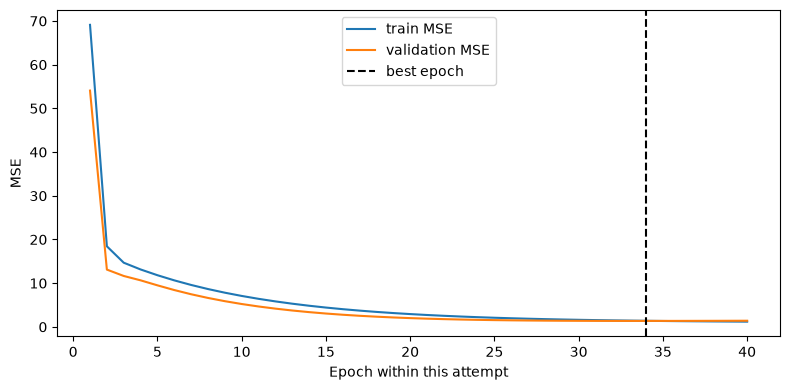

First validation MSE: 54.070
Best validation MSE: 1.357
Final validation MSE: 1.400


In [8]:
import matplotlib.pyplot as plt

epochs = [result.epoch for result in training_result.epochs]
train_mse = [result.metrics["train_mse"] for result in training_result.epochs]
validation_mse = [result.metrics["validation_mse"] for result in training_result.epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_mse, label="train MSE")
plt.plot(epochs, validation_mse, label="validation MSE")
plt.axvline(training_result.best_epoch, color="black", linestyle="--", label="best epoch")
plt.xlabel("Epoch within this attempt")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

print(f"First validation MSE: {validation_mse[0]:.3f}")
print(f"Best validation MSE: {min(validation_mse):.3f}")
print(f"Final validation MSE: {validation_mse[-1]:.3f}")

## Section 5: Evaluate independently

In [9]:
from bovi_core.ml import EvaluationContext
from scikit_sgd import ScikitSGDEvaluator

evaluation_context = EvaluationContext(
    evaluation_id=uuid4(),
    split="validation",
    model_version="notebook-last",
    training_run_id=run_id,
    output_dir=output_dir / "evaluation",
)
evaluation_result = ScikitSGDEvaluator(model, evaluation_config).evaluate(
    dataloaders["validation"],
    evaluation_context,
)

print(f"Status: {evaluation_result.status}")
print(f"Examples: {evaluation_result.num_examples}")
for name, value in evaluation_result.metrics.items():
    print(f"  {name}: {value:.4f}")

Status: completed
Examples: 6
  mse: 1.4002
  mae: 0.8620
  r2: 0.9344


## Section 6: Restore and resume a new attempt

In [10]:
from bovi_core.ml import ResolvedCheckpoint

last_checkpoint_path = output_dir / "checkpoints" / "last.joblib"
resolved_checkpoint = ResolvedCheckpoint(
    format=training_result.last_checkpoint.format,
    source_uri=training_result.last_checkpoint.uri,
    local_path=last_checkpoint_path,
)
resumed_model = provider.restore_checkpoint(model_config, resolved_checkpoint)

resume_run_id = uuid4()
resume_context = TrainingContext(
    run_id=resume_run_id,
    resumed_from_run_id=run_id,
    reason="resume demonstration",
    output_dir=Path(gettempdir()) / "bovi-scikit-sgd" / str(resume_run_id),
)
resume_config = training_config.model_copy(update={"epochs": 2, "early_stopping_patience": None})
resume_result = ScikitSGDTrainer(
    model=resumed_model,
    dataloaders=dataloaders,
    config=resume_config,
    context=resume_context,
).train()

print(f"Resumed from: {resume_context.resumed_from_run_id}")
print(f"New run ID: {resume_result.run_id}")
print(f"Epochs in new attempt: {[epoch.epoch for epoch in resume_result.epochs]}")
print(f"Status: {resume_result.status}")

Resumed from: 8faded58-8cf5-40d9-9f5c-761210d87e69
New run ID: ef4fba53-fe6e-4841-acc2-b63ec125cb92
Epochs in new attempt: [1, 2]
Status: completed


## Summary

The concrete pipeline is:

`YAML -> typed configs -> JSON source -> transforms -> dataset -> dataloaders -> provider -> model -> trainer -> TrainingResult -> evaluator`

Important boundaries demonstrated here:

- The model config defines the estimator's stable input contract.
- The training config defines one attempt's runtime behavior.
- The context carries identity, output location, reason, and an optional deadline.
- Every attempt numbers its epochs from one, including a resumed attempt.
- The result contains metrics and checkpoint references, not heavyweight model copies.
- Evaluation remains separate from training.
- An orchestrator can replace this local flow with a federated flow without changing the trainer contract.